# FBS Detection — LightGBM

LightGBM model for False Base Station detection. Part of the AI model benchmark — see `fbs_model_benchmark.ipynb` for comparative analysis of training overhead and detection performance.

In [73]:
import json
import time
import pandas as pd
import numpy as np
from pathlib import Path

from lightgbm import LGBMClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    matthews_corrcoef,
)
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Preprocessed Splits

Run `fbs_dataset_analysis.ipynb` first to produce `fbs_train.csv`, `fbs_test.csv`, and `fbs_class_weights.json`.

In [74]:
TRAIN_PATH = Path("fbs_train.csv")
TEST_PATH  = Path("fbs_test.csv")
CW_PATH    = Path("fbs_class_weights.json")

for p in [TRAIN_PATH, TEST_PATH]:
    if not p.exists():
        raise FileNotFoundError(
            f"Split file not found: {p}\n"
            "Run fbs_dataset_analysis.ipynb first to generate all split files."
        )

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

feature_cols = [c for c in train_df.columns if c not in ("label", "source")]

X_train = train_df[feature_cols].values.astype(np.float32)
y_train = train_df["label"].values
X_test  = test_df[feature_cols].values.astype(np.float32)
y_test  = test_df["label"].values

cw = {int(k): v for k, v in json.load(open(CW_PATH)).items()} if CW_PATH.exists() else "balanced"

print(f"Train: {len(X_train):,} | Test: {len(X_test):,} | Features: {len(feature_cols)}")

Train: 4,335 | Test: 1,084 | Features: 762


## 2. Train LightGBM

In [75]:
model = LGBMClassifier(
    n_estimators=200,
    num_leaves=31,
    max_depth=6,
    min_child_samples=20,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
    verbose=-1,
)

t0 = time.perf_counter()
model.fit(X_train, y_train)
train_time_sec = time.perf_counter() - t0
print(f"LightGBM training complete in {train_time_sec:.2f}s")

LightGBM training complete in 0.27s


## 3. Detection Overhead (Inference Latency)

In [76]:
n_test = len(X_test)
t0 = time.perf_counter()
y_pred = model.predict(X_test)
inference_sec = time.perf_counter() - t0
ms_per_sample = (inference_sec / n_test) * 1000
print(f"Batch inference: {inference_sec:.4f}s ({n_test} samples)")
print(f"Per-sample latency: {ms_per_sample:.4f} ms")

Batch inference: 0.0026s (1084 samples)
Per-sample latency: 0.0024 ms


/home/ubuntu-chan/Documents/Github/airgap/ai-detection/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 4. Detection Quality (Evaluation)

In [77]:
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("=" * 55)
print("Test Set (Final)")
print("=" * 55)
print(f"  Accuracy : {acc:.4f}")
print(f"  MCC      : {mcc:.4f}")
print(f"  ROC-AUC  : {auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Normal", "Attack"]))

Test Set (Final)
  Accuracy : 0.9170
  MCC      : 0.8339
  ROC-AUC  : 0.9620

              precision    recall  f1-score   support

      Normal       0.92      0.92      0.92       544
      Attack       0.92      0.92      0.92       540

    accuracy                           0.92      1084
   macro avg       0.92      0.92      0.92      1084
weighted avg       0.92      0.92      0.92      1084



/home/ubuntu-chan/Documents/Github/airgap/ai-detection/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


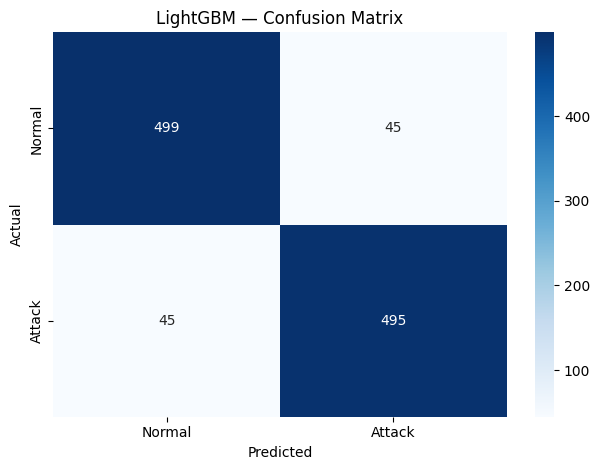

In [78]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Attack"], yticklabels=["Normal", "Attack"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LightGBM — Confusion Matrix")
plt.tight_layout()
plt.show()

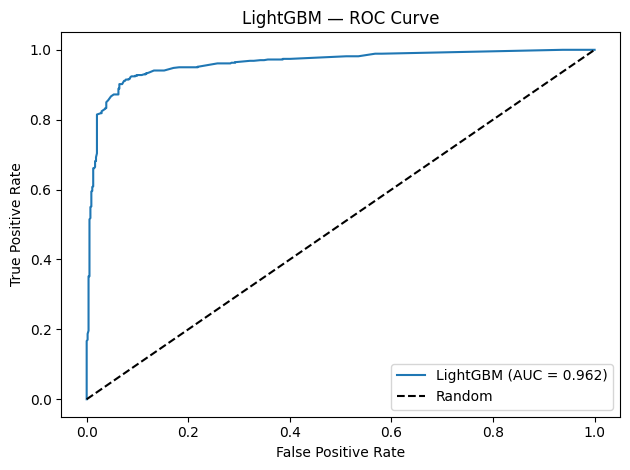

In [79]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"LightGBM (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LightGBM — ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Export Metrics for Benchmark

In [80]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics = {
    "model": "LightGBM",
    "train_time_sec": train_time_sec,
    "inference_batch_sec": inference_sec,
    "inference_ms_per_sample": ms_per_sample,
    "accuracy": acc,
    "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
    "roc_auc": auc,
    "mcc": mcc,
}

with open("fbs_benchmark_lightgbm.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved fbs_benchmark_lightgbm.json")

Saved fbs_benchmark_lightgbm.json
